**Actividad**

*Analisis Estadístico en una Empresa Manufacturera caso mencionado anteriormente*


**Caso de estudio**

La empresa manufacturera TecnoFábrica S.A.S. desea analizar información relacionada con
las condiciones laborales, económicas y de bienestar de sus trabajadores. Para ello, ha
recolectado variables demográficas, económicas, de transporte y salud ocupacional, con el
fin de fortalecer la toma de decisiones desde gestión humana y productividad.


**PARTE 1. DISTRIBUCIONES DE PROBABILIDAD**


*Objetivo*

Aplicar distribuciones de probabilidad para modelar situaciones reales dentro de la empresa
manufacturera.

**Actividades** 

1. -Determine la probabilidad de seleccionar un trabajador que tenga vivienda propia.
2. -Calcule la probabilidad de seleccionar un trabajador cuyo ingreso sea superior al
promedio de la empresa.
3. -Determine la probabilidad de encontrar trabajadores con más de 2 hijos.
4. -Halle la probabilidad de que un trabajador tarde más de 60 minutos en llegar a la
empresa.
5. -Determine la probabilidad de seleccionar una mujer dentro de la muestra.
6. -Calcule la probabilidad conjunta de que un trabajador tenga vivienda propia y nivel
educativo universitario.
7. -Determine la probabilidad de seleccionar un trabajador cuyo gasto diario de
transporte sea menor a un valor determinado por el docente.
8. -Utilice una distribución de frecuencias para calcular probabilidades acumuladas de
la variable EDAD.
9. -Determine si la variable INGRESO presenta comportamiento cercano a una
distribución normal mediante histogramas y pruebas estadísticas.
10. -Interprete los resultados obtenidos y explique cómo podrían ayudar a la empresa en
la toma de decisiones.

In [87]:
import pandas as pd
import numpy as np
import scipy as sc
import statsmodels as stm
import matplotlib as plt
import seaborn as sns

df=pd.read_excel("DATOS (2).xlsx")
pd.set_option('display.max_rows', None)
df



,N,GENERO,EDAD,ESTADO_CIVIL,HIJOS,PESO_ANTES_DIETA,PESO_DESPUES_DIETA,NIVEL_EDUCATIVO,INGRESO,GASTOS,CALIFICACION_SERVICIO_TRANSPORTE,TIEMPO_RECORRIDO,GASTO_DIARIO_TRANSPORTE,VIVIENDA,PERSONAS_HOGAR,PERSONAS_EDAD_TRABAJAR,NUMERO_PERSONAS_EDAD_TRABAJAR
0,1,MUJER,19,SOLTERO,0,48,48,TECNICO,800,750,BUENO,15,3,NO,5,4,2
1,39,MUJER,19,SOLTERO,0,48,48,TECNICO,800,750,BUENO,15,3,NO,5,4,2
2,9,HOMBRE,19,CASADO,0,62,60,TECNICO,1650,1300,EXCELENTE,38,3,NO,5,3,1
3,44,HOMBRE,19,CASADO,0,62,60,TECNICO,1650,1300,EXCELENTE,38,3,NO,5,3,1
4,57,HOMBRE,19,CASADO,0,62,60,TECNICO,1650,1300,EXCELENTE,38,3,NO,5,3,1
5,20,HOMBRE,20,SOLTERO,0,75,77,TECNICO,600,600,BUENO,10,3,NO,1,1,1
6,81,HOMBRE,20,SOLTERO,0,75,77,TECNICO,600,600,BUENO,10,3,NO,1,1,1
7,78,HOMBRE,22,SOLTERO,1,66,64,TECNICO,650,400,BUENO,15,5,NO,2,2,2
8,88,HOMBRE,22,SOLTERO,1,66,64,TECNICO,650,400,BUENO,15,5,NO,2,2,2
9,11,HOMBRE,22,SOLTERO,0,70,67,PRIMARIA,600,500,MUY_BUENO,45,5,SI,2,2,2


1: -*Determine la probabilidad de seleccionar un trabajador que tenga vivienda propia.*

In [88]:
df=pd.read_excel("DATOS (2).xlsx")
total_trabajadores=len(df) #usamos la funcion len para traer todos los valores de nuestro df (dataframe)
vivienda_propia=len(df[df["VIVIENDA"]=='SI']) #este codigo me calcula el numero de trabajadores que tiene vivienda propia ya que lo filtre por esos usamos el ==
# 3. Cálculo de la probabilidad (casos favorables / casos totales)
probabilidad_vivienda = vivienda_propia/ total_trabajadores
print(f"La probabilidad es: {probabilidad_vivienda:.4f} (es decir, el {probabilidad_vivienda * 100:.2f}%)")

La probabilidad es: 0.5455 (es decir, el 54.55%)


2:*-Calcule la probabilidad de seleccionar un trabajador cuyo ingreso sea superior al promedio de la empresa.*

In [89]:
ingreso_promedio=df["INGRESO"].mean() #calculamos el ingreso promedio en esta celda 
ingreso_superior=len(df[df["INGRESO"] >ingreso_promedio])#en esta celda se calculo haciendo un filtro sobre los ingresos mayores a la media
print(f"El promedio es: {ingreso_promedio:.2f}")
print(f"Trabajadores que lo superan: {ingreso_superior}")
print(f"La probabilidad es: {ingreso_superior / len(df):.4f} (es decir, el {(ingreso_superior / len(df)) * 100:.2f}%)")
# los print denotan cada calculo correspondiente y los muestra en el codigo

El promedio es: 1796.36
Trabajadores que lo superan: 34
La probabilidad es: 0.3864 (es decir, el 38.64%)


3:*-Determine la probabilidad de encontrar trabajadores con más de 2 hijos.*

In [90]:
total_trabajadores=len(df) # en esta celda volvimos a definir la variable total de los trabajadores
trabajadores_mayor_a_2_hijos=len(df[df["HIJOS"]>2]) #en esta celda definimos la variable trabajadores_mayor_a_2_hijos y posteriormente la filtramos por la columna HIJOS y finalmente aplicamos la condicion correspondiente (< a 2)
print(f"La probabilidad es: {trabajadores_mayor_a_2_hijos / len(df):.4f} (es decir, el {(trabajadores_mayor_a_2_hijos /len(df)) *100:.2f}%)")
#finalmente el print final es para demostrarnos la probabilidad en porcentaje haciendo el calculo correspondiente  dividido por la muestra total y multiplicado por el 100%

La probabilidad es: 0.2955 (es decir, el 29.55%)


4:*-Halle la probabilidad de que un trabajador tarde más de 60 minutos en llegar a la empresa.*

In [91]:
import scipy.stats as stats
#paso 1: calculare el promedio y la desviacion estandar 
variables_estadisticas= df["TIEMPO_RECORRIDO"].agg(['mean','std'])

#paso 2: extraere cada valor correspondiente 
tiempo_promedio= variables_estadisticas['mean']
tiempo_desviacion= variables_estadisticas['std']

# paso 3: calcule la probabilidad usando la distribucion normal
probabilidad_normal = 1 - stats.norm.cdf(60, loc=tiempo_promedio, scale=tiempo_desviacion)

#paso 4: imprimir los resultados 
print(f"El tiempo promedio : {tiempo_promedio:.2f} minutos")
# Renderizamos unidades de forma sencilla
print(f" La desviación estándar es : {tiempo_desviacion:.2f} minutos")
print(f"La probabilidad es: {probabilidad_normal:.4f} (es decir, el {probabilidad_normal * 100:.2f}%)")


El tiempo promedio : 30.25 minutos
 La desviación estándar es : 11.27 minutos
La probabilidad es: 0.0041 (es decir, el 0.41%)


5:*-Determine la probabilidad de seleccionar una mujer dentro de la muestra.*

In [92]:
#paso 1: definire la variable de nuevo total de trabajadores

total_trabajadores=len(df)

#paso 2: filtrare por la columna genero aplicando la misma logica en el codigo que use en los puntos 1,2 y 3
data_mujer=len(df[df["GENERO"]=='MUJER'])

#paso 3: caculare la probabilidad correspondiente
probabilidad_mujer=data_mujer/total_trabajadores

#paso 4: imprimir los resultados correspondientes 
print(f"La probabilidad es: {probabilidad_mujer:.4f} (es decir, el {probabilidad_mujer *100:.2f}%)")

La probabilidad es: 0.5000 (es decir, el 50.00%)


6:*- Calcule la probabilidad conjunta de que un trabajador tenga vivienda propia y nivel educativo universitario.*


In [93]:
# paso 1: definir el total de trabajadores
total_trabajadores = len(df)

# paso 2: filtrar por vivienda propia Y nivel educativo universitario al tiempo
filtro_conjunto = df[(df["VIVIENDA"] == "SI") & (df["NIVEL_EDUCATIVO"].str.upper() == "UNIVERSITARIO")]
data_conjunta = len(filtro_conjunto)

# paso 3: calcular la probabilidad conjunta
probabilidad_conjunta = data_conjunta / total_trabajadores

# paso 4: imprimir los resultados correspondientes
print(f"Trabajadores con vivienda propia y universidad: {data_conjunta}")
print(f"La probabilidad conjunta es: {probabilidad_conjunta:.4f} (es decir, el {probabilidad_conjunta * 100:.2f}%)")


Trabajadores con vivienda propia y universidad: 13
La probabilidad conjunta es: 0.1477 (es decir, el 14.77%)


7:-*Determine la probabilidad de seleccionar un trabajador cuyo gasto diario de transporte sea menor a un valor determinado por el docente*.


In [94]:
# paso 1: calcular el promedio y la desviacion estandar de GASTO_TRANSPORTE
variables_transporte = df["GASTOS"].agg(['mean', 'std'])

gasto_promedio = variables_transporte['mean']
gasto_desviacion = variables_transporte['std']

# paso 2: definir el valor limite 
valor_limite = 3500

# paso 3: calcular la probabilidad MENOR A (directo con stats.norm.cdf, sin el "1 -")
probabilidad_transporte = stats.norm.cdf(valor_limite, loc=gasto_promedio, scale=gasto_desviacion)

# paso 4: imprimir los resultados correspondientes
print("--- PROBABILIDAD DE GASTO EN TRANSPORTE (DISTRIBUCIÓN NORMAL) ---")
print(f"Gasto promedio: ${gasto_promedio:.2f}")
print(f"Desviación estándar: ${gasto_desviacion:.2f}")
print(f"Probabilidad de gastar menos de ${valor_limite:,}: {probabilidad_transporte:.4f} (es decir, el {probabilidad_transporte * 100:.2f}%)")

--- PROBABILIDAD DE GASTO EN TRANSPORTE (DISTRIBUCIÓN NORMAL) ---
Gasto promedio: $1522.16
Desviación estándar: $1123.70
Probabilidad de gastar menos de $3,500: 0.9608 (es decir, el 96.08%)


8:-*Utilice una distribución de frecuencias para calcular probabilidades acumuladas de la variable EDAD.*


In [95]:
# Paso 1: Crear la tabla de frecuencias de la columna EDAD
tabla_edad = df["EDAD"].value_counts().sort_index().reset_index()
tabla_edad.columns = ["Edad", "Frecuencia_Absoluta"]

# Paso 2: Calcular la frecuencia acumulada
tabla_edad["Frecuencia_Acumulada"] = tabla_edad["Frecuencia_Absoluta"].cumsum()

# Paso 3: Calcular la probabilidad acumulada (Frecuencia Acumulada / Total de trabajadores)
total_trabajadores = len(df)
tabla_edad["Probabilidad_Acumulada"] = tabla_edad["Frecuencia_Acumulada"] / total_trabajadores
tabla_edad["Probabilidad_Acumulada_%"] = tabla_edad["Probabilidad_Acumulada"] * 100

# Paso 4: Mostrar la tabla resultante
print("--- DISTRIBUCIÓN DE FRECUENCIAS Y PROBABILIDAD ACUMULADA (EDAD) ---")
print(tabla_edad.to_string(index=False))

--- DISTRIBUCIÓN DE FRECUENCIAS Y PROBABILIDAD ACUMULADA (EDAD) ---
 Edad  Frecuencia_Absoluta  Frecuencia_Acumulada  Probabilidad_Acumulada  Probabilidad_Acumulada_%
   19                    5                     5                0.056818                  5.681818
   20                    2                     7                0.079545                  7.954545
   22                    4                    11                0.125000                 12.500000
   23                    2                    13                0.147727                 14.772727
   24                    2                    15                0.170455                 17.045455
   25                    1                    16                0.181818                 18.181818
   27                    1                    17                0.193182                 19.318182
   28                    2                    19                0.215909                 21.590909
   29                    2               

9:-*Determine si la variable INGRESO presenta comportamiento cercano a una distribución normal mediante histogramas y pruebas estadísticas.*
 

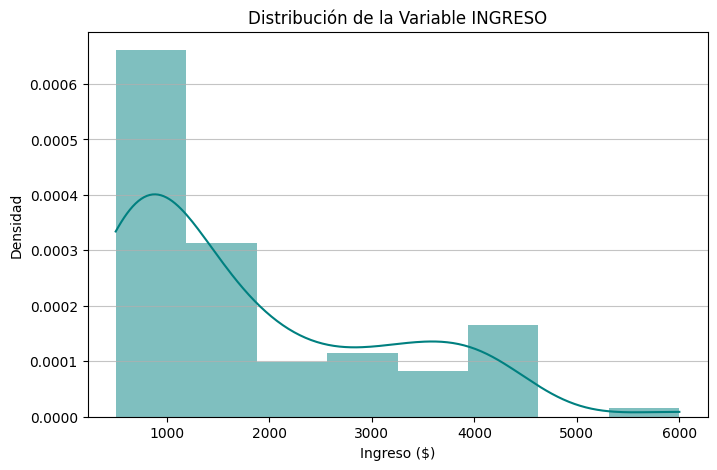

--- PRUEBA ESTADÍSTICA DE NORMALIDAD (SHAPIRO-WILK) ---
Estadístico de prueba: 0.8417
Valor p (p-value): 0.00000
Veredicto: La variable INGRESO NO presenta un comportamiento normal (p <= 0.05).


In [96]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
#paso: 1 Gráfico: Histograma con curva de densidad ajustada
plt.figure(figsize=(8, 5))
sns.histplot(df["INGRESO"], kde=True, color="teal", stat="density", linewidth=0)
plt.title("Distribución de la Variable INGRESO")
plt.xlabel("Ingreso ($)")
plt.ylabel("Densidad")
plt.grid(axis='y', alpha=0.75)
plt.show()

#paso: 2  Prueba estadística de Normalidad (Shapiro-Wilk)
stat, p_value = stats.shapiro(df["INGRESO"])

print("--- PRUEBA ESTADÍSTICA DE NORMALIDAD (SHAPIRO-WILK) ---")
print(f"Estadístico de prueba: {stat:.4f}")
print(f"Valor p (p-value): {p_value:.5f}")

if p_value > 0.05:
    print("Veredicto: La variable INGRESO presenta un comportamiento CERCANO a una distribución normal (p > 0.05).")
else:
    print("Veredicto: La variable INGRESO NO presenta un comportamiento normal (p <= 0.05).")

10:-*Interprete los resultados obtenidos y explique cómo podrían ayudar a la empresa en la toma de decisiones.*

Acorde a los resultados obtenidos en este analisis probabilistico podemos decir que puede ayudar a la empresa por ejemplo a crear una planificacion de bienestar esto lo podemos concluir al saber las edades de los trabajadores y al calcular cuantos de ellos tienen una vivienda propia ademas de saber cuantos tienen un nivel educativo equivalente al profesional lo cual es bajo (14.77%) 

Otro aspecto a tener en cuenta es la estructura salarial como lo pudimos concluir en el punto final no hay ingresos con un comportamiento normal esto puede replantear sus politicas salariales  y  balancearlas generando competitividad interna  ya que esta muy desigual en cuestion de salarios esto puede ayudar a los departamentos de recursos humanos y finanzas a buscar esrategias para sanear esa disparidad. 

finalmente tener el conocimiento de la logistica y comportamiento frente al transporte nos muestra que la Probabilidad de gastar menos de $3,500:  es  el 0.9608 (es decir, el 96.08%) esto nos indica que puede ayudar a la organizacion a ajustar subsidios de transporte que favorezca a los empleados y asi evitar la desercion laboral o evaluar un sobrecosto que implemente la contratacion de rutas para los empleados y asi mejorar la calidad de vida de los trabajadores ya que si se mejora la calidad de vida es mas probable que se incremente la productividad , recordemos que un empleado bien remunerado (no es solo lo economico ) si no con bienestar emocional , social y psicologico es altamente mas efectivo , eficaz y productivo que uno que no tiene las condiciones anteriormente mencionadas bajo estudio del analisis expuesto.